# 09 · Honest validation and model selection

**ROBT613 · Brain–Computer Interfaces** | Teaching session + independent lab

## Goal
Compare classifiers with nested run-grouped validation, distinguish uncertainty units and diagnose leakage.

**Data:** EEGBCI subject 1, three independent run groups

Run cells from top to bottom in a fresh CPU runtime. No previous notebook state is required.

## The question for today

Two models differ by five percentage points. Was one better, or did the evaluation accidentally reward reuse of the same recording? We turn “train/test split” into an explicit scientific claim about future use.

### By the end you should be able to

- Match run, session and participant grouping to the target use case.
- Explain inner selection and outer evaluation in nested validation.
- Calculate class-balanced metrics and distinguish scores from uncertainty.
- Identify every learned preprocessing operation that must be refitted within folds.

**How to work:** predict each result before running it, execute one cell at a time, and write a short interpretation. The worked examples use small controlled arrays; the later walkthrough uses the dataset stated above. End-of-lesson exercises contain editable workspaces. A pending exercise message is expected until you complete its function.

## Setup
The first cell installs the tested core versions in Colab. Downloads are cached in `mne_data/`; a new Colab runtime loses that cache. A failed download is an error, never silently replaced by synthetic data.

In [1]:
# Colab: install before importing numerical libraries. Restart if pip requests it.
import sys, subprocess, os
if 'google.colab' in sys.modules:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                           'mne==1.13.2', 'moabb==1.7.2'])
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
from scipy import signal
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (balanced_accuracy_score, roc_auc_score,
                             ConfusionMatrixDisplay, classification_report)
from sklearn.model_selection import (GroupKFold, cross_validate, GridSearchCV)
SEED = 613
rng = np.random.default_rng(SEED)
DATA_ROOT = Path(os.environ.get('BCI_DATA', './mne_data')).resolve()
DATA_ROOT.mkdir(parents=True, exist_ok=True)
os.environ['MNE_DATA'] = str(DATA_ROOT)
mne.set_log_level('WARNING')
plt.rcParams.update({'figure.figsize': (9, 4), 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})
import importlib.metadata as metadata
print({p: metadata.version(p) for p in ['mne','moabb','numpy','scipy','scikit-learn']})
print('Dataset cache:', DATA_ROOT)

{'mne': '1.13.2', 'moabb': '1.7.2', 'numpy': '2.1.3', 'scipy': '1.15.3', 'scikit-learn': '1.6.1'}
Dataset cache: <dataset-cache>


### Choose the prediction problem before the split

A random trial split asks whether a model generalizes to another trial under closely shared recording conditions. A held-out run asks a stronger question about a new recording block. A held-out session tests changes across sessions; a held-out participant tests transfer across people. None is a substitute for another. The partition is part of the experiment, not a final programming detail.

Adjacent EEG windows can share samples, artifacts and slow changes. Even non-overlapping trials in the same run share impedance, fatigue, amplifier conditions and task order. Grouped cross-validation holds entire groups out. If the intended deployment has a temporal direction, ensure the evaluation also respects that direction; ordinary grouped folds do not by themselves simulate chronological deployment.

### Learn only from the training partition

A transformation is “learned” whenever it estimates parameters from data. Standardization estimates means and variances. PCA estimates directions. CSP estimates label-dependent spatial filters. Feature selection estimates which columns to keep. All belong inside the fold when evaluating the full pipeline. A fixed physical unit conversion does not estimate a parameter and can be applied consistently in advance.

Hyperparameters include component count, regularization, bands selected by performance and decision thresholds selected by performance. Repeatedly trying them against a test set makes the test set part of the training process, even if no gradient was computed on it.

### Two loops with different jobs

For each outer fold, set aside the outer test group. Within the remaining groups, inner validation selects one candidate configuration. Refit that configuration on all outer training data, then evaluate once on the outer test group. The outer scores describe the model-selection procedure, not one model fitted to every observation.

$$\hat h_k=\arg\max_h\operatorname{CV}_{inner}(h;D_{train,k}),\qquad s_k=\operatorname{score}(\operatorname{fit}(\hat h_k,D_{train,k}),D_{test,k}).$$

The nested example has few groups, so estimates can be noisy. A table of individual run scores is more informative than a mean with many decimal places. Fold scores are not independent participants; treating them as such produces unjustified precision.

### Metrics and uncertainty

Balanced accuracy averages class recalls, $BA=K^{-1}\sum_k TP_k/(TP_k+FN_k)$. ROC AUC describes ranking for a binary score; it does not choose a useful operating threshold. A confusion matrix shows which classes are confused but depends on a decision rule. Report the class counts and the evaluation unit alongside any metric.

Permutation tests require exchangeability under the null. Arbitrarily shuffling individual trials can break temporal or block structure. Bootstrap intervals likewise depend on the unit resampled: trials, runs and participants support different claims. This lesson teaches the reasoning and avoids presenting three folds as a precise population confidence interval.

### Worked example · imbalanced accuracy

Construct a 90/10 dataset and predict only the majority class.

**Before running:** state your prediction and the assumption behind it.

In [2]:
from sklearn.metrics import accuracy_score
demo_y=np.array([0]*90+[1]*10)
demo_pred=np.zeros(100,dtype=int)
print('Accuracy:',accuracy_score(demo_y,demo_pred),'Balanced accuracy:',balanced_accuracy_score(demo_y,demo_pred))

Accuracy: 0.9 Balanced accuracy: 0.5


**Read the result.** Ninety percent accuracy can coexist with zero sensitivity to the minority class. The metric must reflect the scientific objective.

**Pause and explain:** point to one computed value that supports this interpretation.

### Worked example · inspect grouped folds

Use three groups and print the identifiers in each partition. Assert that no group crosses a boundary.

**Before running:** state your prediction and the assumption behind it.

In [3]:
demo_groups=np.repeat(['run A','run B','run C'],4)
demo_y=np.tile([0,1,0,1],3)
for train_idx,test_idx in GroupKFold(3).split(np.zeros((12,1)),demo_y,demo_groups):
    assert set(demo_groups[train_idx]).isdisjoint(demo_groups[test_idx])
    print('Train:',np.unique(demo_groups[train_idx]),'Test:',np.unique(demo_groups[test_idx]))

Train: ['run A' 'run B'] Test: ['run C']
Train: ['run A' 'run C'] Test: ['run B']
Train: ['run B' 'run C'] Test: ['run A']


**Read the result.** Checking group identities is more direct than assuming a splitter did what the experiment required.

**Pause and explain:** point to one computed value that supports this interpretation.

### Guided experiment · fitting the scaler

Compare training-only and pooled means when the held-out data have shifted.

**Before running:** state your prediction and the assumption behind it.

In [4]:
demo_train=np.array([[0.],[1.],[2.]])
demo_test=np.array([[10.],[11.]])
demo_scaler=StandardScaler().fit(demo_train)
print('Training mean:',demo_scaler.mean_)
print('Pooled mean:',np.vstack([demo_train,demo_test]).mean(axis=0))
print('Test transformed by training parameters:',demo_scaler.transform(demo_test).ravel())

Training mean: [1.]
Pooled mean: [4.8]
Test transformed by training parameters: [11.02270384 12.24744871]


**Read the result.** The shifted test values should remain shifted. Using their mean during fitting partly adapts to the evaluation distribution and changes the question being measured.

**Pause and explain:** point to one computed value that supports this interpretation.

### Checkpoint · selection optimism

Imagine twenty equally good candidates whose validation estimates contain noise. Compare the maximum observed estimate with their shared true value.

**Before running:** state your prediction and the assumption behind it.

In [5]:
demo_rng=np.random.default_rng(613)
demo_estimates=.6+demo_rng.normal(0,.05,size=(1000,20))
print('Mean of all estimates:',demo_estimates.mean())
print('Mean selected maximum:',demo_estimates.max(axis=1).mean())

Mean of all estimates: 0.6003243336953168
Mean selected maximum: 0.6935301026005202


**Read the result.** Selecting the largest noisy estimate inflates its apparent performance. An untouched outer evaluation is needed even when every candidate has identical true quality.

**Pause and explain:** point to one computed value that supports this interpretation.

## Apply the ideas to the complete pipeline

The next stages use the real recording or the explicitly labeled simulation described in the lesson. Keep preprocessing, feature extraction and evaluation decisions visible. Read each stage’s explanation before running its code.

### Method reference for the pipeline

A test score estimates performance on the distribution represented by the held-out unit. Holding out trials, runs, sessions and people answers different questions. If adjacent windows share EEG samples, random window splitting can make generalization look much stronger than it is.

Nested cross-validation separates model selection from evaluation: for each outer split, choose hyperparameters using only inner folds of the outer training set, refit, then score the outer test set once. For balanced accuracy $BA=K^{-1}\sum_k TP_k/(TP_k+FN_k)$. A confusion matrix reveals which classes contribute to a mean score.

A bootstrap must resample independent units. Thousands of correlated epochs from one participant do not provide thousands of independent estimates of population performance. Three run scores are too few for a precise uncertainty estimate. Permutation tests must respect exchangeability (e.g. experimental blocks); shuffling arbitrary overlapping flash labels is not automatically valid.

## Load an auditable benchmark
This lesson deliberately keeps all three run IDs.

Preserve run groups while loading and processing each run separately. The nested evaluation needs those identifiers to distinguish inner development from outer assessment.

In [6]:
from mne.datasets import eegbci
runs = [4, 8, 12]  # ALL are imagined left versus right fist, not hands versus feet
parts, groups = [], []
for run in runs:
    paths = eegbci.load_data(1, [run], path=DATA_ROOT, update_path=False)
    raw_run = mne.io.read_raw_edf(paths[0], preload=True, verbose=False)
    eegbci.standardize(raw_run)
    raw_run.set_montage('standard_1005')
    raw_run.set_eeg_reference('average', projection=False)
    raw_run.filter(8, 30, fir_design='firwin')
    events, _ = mne.events_from_annotations(raw_run, event_id={'T1': 1, 'T2': 2})
    ep = mne.Epochs(raw_run, events, {'left': 1, 'right': 2}, tmin=0.5,
                    tmax=3.5, baseline=None, preload=True, picks='eeg',
                    reject_by_annotation=True)
    parts.append(ep)
    groups.extend([run] * len(ep))
epochs = mne.concatenate_epochs(parts)
X = epochs.get_data(copy=True)
y = epochs.events[:, 2] - 1
groups = np.asarray(groups)
print('Epochs:', X.shape, 'run counts:', pd.Series(groups).value_counts().to_dict())

/tmp/ipykernel_452340/2492561078.py:8: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  raw_run.set_montage('standard_1005')


/tmp/ipykernel_452340/2492561078.py:8: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  raw_run.set_montage('standard_1005')


Epochs: (45, 64, 481) run counts: {4: 15, 8: 15, 12: 15}


/tmp/ipykernel_452340/2492561078.py:8: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  raw_run.set_montage('standard_1005')
/tmp/ipykernel_452340/2492561078.py:17: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epochs = mne.concatenate_epochs(parts)


### Inspect and interpret

Inspect group sizes and class balance. Consider whether the available number of groups is adequate for a large hyperparameter search.

**Record in your notes:** the relevant shape/count or metric, the units where applicable, and one limitation of the inference.

## Nested model comparison
With three runs, each outer training fold contains two runs, so the inner loop uses two groups. All learned transformations remain inside the pipeline.

The outer loop holds out one run. Inner grouped search chooses CSP component count using only the other two runs. Each row records the held-out result for a complete model-selection procedure.

   held_out_run  balanced_accuracy  components
0            12           0.616071           2
1             8           0.660714           4
2             4           0.562500           4


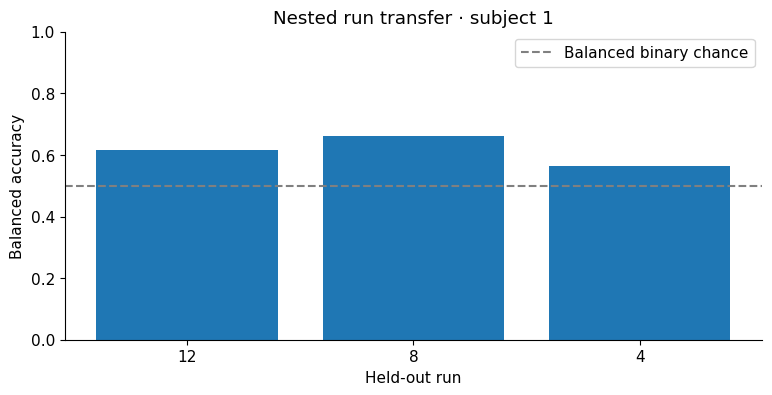

In [7]:
from mne.decoding import CSP
outer=GroupKFold(3)
rows=[]
for fold,(tr,te) in enumerate(outer.split(X,y,groups),1):
    model=make_pipeline(CSP(n_components=4,reg='ledoit_wolf',log=True),
                        LinearDiscriminantAnalysis(solver='lsqr',shrinkage='auto'))
    search=GridSearchCV(model,{'csp__n_components':[2,4]},cv=GroupKFold(2),
                        scoring='balanced_accuracy',n_jobs=1)
    search.fit(X[tr],y[tr],groups=groups[tr])
    score=balanced_accuracy_score(y[te],search.predict(X[te]))
    rows.append({'held_out_run':int(groups[te][0]),'balanced_accuracy':score,
                 'components':search.best_params_['csp__n_components']})
results=pd.DataFrame(rows)
print(results)
fig,ax=plt.subplots()
ax.bar(results.held_out_run.astype(str),results.balanced_accuracy)
ax.axhline(.5,color='gray',linestyle='--',label='Balanced binary chance')
ax.set(ylim=(0,1),xlabel='Held-out run',ylabel='Balanced accuracy',title='Nested run transfer · subject 1')
ax.legend(); plt.show()

### Inspect and interpret

Compare outer scores, chosen configurations and run-specific errors. A variable selected configuration may indicate that the calibration sample is too small to identify one stable optimum.

**Record in your notes:** the relevant shape/count or metric, the units where applicable, and one limitation of the inference.

## Independent practice

Work through the tasks in order. Exercise 1 includes a small implementation check; passing it verifies the stated example, not every possible input. For the investigations, save a labeled figure or table and a short explanation. Use copies of data objects when changing preprocessing, and preserve any held-out evaluation partition.

**Submission:** your completed notebook, the requested outputs, and a brief exit-ticket response. The notebook runs before exercises are completed; “pending” means your work is still required.

### Exercise 1 · Group assertion

Implement groups_disjoint to return whether train and test contain no shared group identifiers.

In [8]:
def groups_disjoint(train_groups, test_groups):
    # TODO: return a Boolean.
    return None

In [9]:
answer=groups_disjoint(['A','B'],['C'])
if answer is not None:
    assert answer
    assert not groups_disjoint(['A','B'],['B','C'])
    print('Group checks passed.')
else: print('Exercise pending: implement groups_disjoint.')

Exercise pending: implement groups_disjoint.


**Your response:**

- Prediction or rationale: _write here_
- Evidence from your result: _write here_
- Interpretation and limitation: _write here_

### Exercise 2 · Split specification

Write three deployment scenarios and choose the correct grouping for each. Include one chronological scenario.

In [10]:
# Your investigation: add code here.
# Keep the original data and final test partition intact.

**Your response:**

- Prediction or rationale: _write here_
- Evidence from your result: _write here_
- Interpretation and limitation: _write here_

### Exercise 3 · Pipeline audit

List all fit calls in the real nested example and state exactly which observations each can see.

In [11]:
# Your investigation: add code here.
# Keep the original data and final test partition intact.

**Your response:**

- Prediction or rationale: _write here_
- Evidence from your result: _write here_
- Interpretation and limitation: _write here_

### Exercise 4 · Search-size experiment

Repeat the numerical optimism experiment with 2, 10 and 100 candidates. Plot selection bias against candidate count.

In [12]:
# Your investigation: add code here.
# Keep the original data and final test partition intact.

**Your response:**

- Prediction or rationale: _write here_
- Evidence from your result: _write here_
- Interpretation and limitation: _write here_

### Exercise 5 · Model comparison

Compare two pipelines using identical outer splits. Report paired run differences and discuss why three runs cannot support broad population claims.

In [13]:
# Your investigation: add code here.
# Keep the original data and final test partition intact.

**Your response:**

- Prediction or rationale: _write here_
- Evidence from your result: _write here_
- Interpretation and limitation: _write here_

### Exercise 6 · Exit ticket

Write a short reviewer response to a result that selected the best frequency band using the final test session.

**Your response:**

- Prediction or rationale: _write here_
- Evidence from your result: _write here_
- Interpretation and limitation: _write here_

## Next steps and sources
[Cross-validation](https://scikit-learn.org/stable/modules/cross_validation.html) · [Common pitfalls](https://scikit-learn.org/stable/common_pitfalls.html).

Record package versions, subject/run IDs, preprocessing, split unit, random seed, and all exclusions with your results. Do not interpret a single participant as a population estimate.